Install & Import Libraries

In [1]:
!pip install tensorflow matplotlib

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

Positional Encoding

In [3]:
def positional_encoding(position, d_model):
    angle_rads = np.arange(position)[:, np.newaxis] / np.power(
        10000,
        (2 * (np.arange(d_model)[np.newaxis, :] // 2)) / np.float32(d_model)
    )

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

pe = positional_encoding(10, 16)

print(pe.shape)

(1, 10, 16)


Visualize Positional Encoding

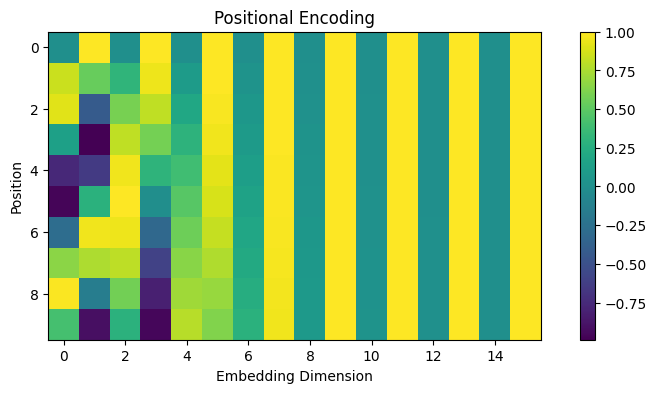

In [4]:
plt.figure(figsize=(10,4))
plt.imshow(pe[0], cmap="viridis")
plt.colorbar()
plt.title("Positional Encoding")
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.show()

Multi-Head Attention

In [5]:
mha = tf.keras.layers.MultiHeadAttention(
    num_heads=4,
    key_dim=16
)

sample = tf.random.normal((1,5,16))

output = mha(sample, sample)

print(output.shape)

(1, 5, 16)


Feed Forward Network

In [6]:
ffn = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(16)
])

ffn_output = ffn(output)

print(ffn_output.shape)

(1, 5, 16)


Layer Normalization

In [7]:
layer_norm = tf.keras.layers.LayerNormalization()

normalized = layer_norm(ffn_output)

print(normalized.shape)

(1, 5, 16)


Residual Connection

In [8]:
final_output = normalized + output

print(final_output.shape)

(1, 5, 16)


Complete Transformer Encoder Block

In [9]:
class TransformerEncoder(tf.keras.layers.Layer):

    def __init__(self):
        super().__init__()

        self.mha = tf.keras.layers.MultiHeadAttention(
            num_heads=4,
            key_dim=16
        )

        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(16)
        ])

        self.norm1 = tf.keras.layers.LayerNormalization()
        self.norm2 = tf.keras.layers.LayerNormalization()

    def call(self, x):

        attn = self.mha(x, x)

        x = self.norm1(x + attn)

        ffn_output = self.ffn(x)

        x = self.norm2(x + ffn_output)

        return x

encoder = TransformerEncoder()

sample = tf.random.normal((1,5,16))

result = encoder(sample)

print(result.shape)

(1, 5, 16)


User Example

In [10]:
sentence = [
    "Natural",
    "Language",
    "Processing",
    "is",
    "Amazing"
]

print("Input Sentence:")

print(sentence)

print("\nTransformer Output Shape:")

print(result.shape)

Input Sentence:
['Natural', 'Language', 'Processing', 'is', 'Amazing']

Transformer Output Shape:
(1, 5, 16)
